In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import ot
import pandas as pd
import time
import random
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from gwgraphs import *

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
### Prototype graph creation functions ###
def create_two_community_graph(nodes_per_community, weight_in_comm, weight_bt_comm):
    # Create an empty graph
    G = nx.Graph()
    
    total_nodes = nodes_per_community * 2
    G.add_nodes_from(range(total_nodes))
    
    # Add edges within communities
    for comm in range(2):
        start = comm * nodes_per_community
        end = start + nodes_per_community
        for i in range(start, end):
            for j in range(i + 1, end):
                G.add_edge(i, j, weight=weight_in_comm)
    
    # Add edges between communities
    for i in range(nodes_per_community):
        for j in range(nodes_per_community):
            G.add_edge(i, j + nodes_per_community, weight=weight_bt_comm)
    
    # Create the adjacency matrix
    adjacency_matrix = np.zeros((total_nodes, total_nodes))
    
    # Fill the matrix according to the block structure
    for i in range(total_nodes):
        for j in range(total_nodes):
            if i == j:
                # Diagonal entries are 0
                adjacency_matrix[i, j] = 0.0
            elif (i < nodes_per_community and j < nodes_per_community) or \
                 (i >= nodes_per_community and j >= nodes_per_community):
                # Within same community
                adjacency_matrix[i, j] = weight_in_comm
            else:
                # Between different communities
                adjacency_matrix[i, j] = weight_bt_comm

    return G, adjacency_matrix


def compute_adjacency_matrix(graph, weight_within, weight_bt):
    """
    Computes the weighted adjacency matrix for a given graph.

    Args:
        graph: A NetworkX graph.
        weight_within: Weight to assign to edges within the same community. 
                      If None, uses the graph's edge weights.
        weight_bt: Weight to assign to edges between different communities.
                  If None, uses the graph's edge weights.

    Returns:
        A numpy array representing the weighted adjacency matrix where the value 
        at (i, j) denotes the weight of the edge between node i and node j.
    """
    import numpy as np
    
    # Initialize a matrix of zeros
    num_nodes = len(graph.nodes)
    adjacency_matrix = np.zeros((num_nodes, num_nodes), dtype=float)
    
    # Assume two communities of equal size
    nodes_per_community = num_nodes // 2

    # Populate the adjacency matrix
    for i, node_i in enumerate(graph.nodes()):
        for j, node_j in enumerate(graph.nodes()):
            if graph.has_edge(node_i, node_j):
                # Determine if nodes are in the same community
                comm_i = node_i // nodes_per_community
                comm_j = node_j // nodes_per_community
                
                if weight_within is not None and weight_bt is not None:
                    # Use user-defined weights
                    if comm_i == comm_j:
                        adjacency_matrix[i, j] = weight_within
                    else:
                        adjacency_matrix[i, j] = weight_bt
                else:
                    # Use original graph weights
                    edge_data = graph.get_edge_data(node_i, node_j)
                    adjacency_matrix[i, j] = edge_data['weight']

    return adjacency_matrix

In [4]:
# ERSBM1
prob_matrix = [
    [0.15, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.15]  # Probabilities related to block 2 connections
]

graphs_er = generate_erdos_renyi_graphs(100, 100, 0.1)
graphs_sbm = generate_sbm_graphs(100, [50, 50], prob_matrix)

full_graph_data = graphs_er + graphs_sbm
# Convert graphs to pairwise distance matrices
#distance_matrices = [    compute_distance_matrix(graph) for graph, label in full_graph_data]
# Prepare labels
labels = [label for graph, label in full_graph_data]

In [5]:
# ERSBM2
prob_matrix2 = [
    [0.45, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.45]  # Probabilities related to block 2 connections
]

graphs_er5 = generate_erdos_renyi_graphs(100, 100, 0.25)
graphs_sbm5 = generate_sbm_graphs(100, [50, 50], prob_matrix2)

full_graph_data5 = graphs_er5 + graphs_sbm5
# Convert graphs to pairwise distance matrices
# distance_matrices5 = [    compute_distance_matrix(graph) for graph, label in full_graph_data5]
# Prepare labels
labels5 = [label for graph, label in full_graph_data5]

In [6]:
graph1, ERSBM1_proto_ER = create_two_community_graph(50, 0.1, 0.1)
graph3, ERSBM2_proto_ER = create_two_community_graph(50, 0.25, 0.25)
ERSBM1_adj_er = [
    compute_adjacency_matrix(graph, 0.1, 0.1) for graph, label in graphs_er
]
ERSBM1_adj_sbm = [
    compute_adjacency_matrix(graph, 0.15, 0.05) for graph, label in graphs_sbm
]
ERSBM2_adj_er5 = [
    compute_adjacency_matrix(graph5, 0.25, 0.25) for graph5, label5 in graphs_er5
]
ERSBM2_adj_sbm5 = [
    compute_adjacency_matrix(graph5, 0.45, 0.05) for graph5, label5 in graphs_sbm5
]
ERSBM1_adj = ERSBM1_adj_er + ERSBM1_adj_sbm
ERSBM2_adj = ERSBM2_adj_er5 + ERSBM2_adj_sbm5

In [7]:
def compute_gromov_wasserstein_distance(adj_matrix1, adj_matrix2):
    """
    Compute the Gromov-Wasserstein distance between two adjacency matrices.
    
    Args:
        adj_matrix1: First adjacency matrix
        adj_matrix2: Second adjacency matrix
    
    Returns:
        The Gromov-Wasserstein distance
    """
    n1, n2 = adj_matrix1.shape[0], adj_matrix2.shape[0]
    
    # Create uniform distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2
    
    # Compute Gromov-Wasserstein distance
    gw_dist = ot.gromov.gromov_wasserstein2(adj_matrix1, adj_matrix2, p, q, 'square_loss')
    
    return np.sqrt(gw_dist)

In [8]:
print("Computing Gromov-Wasserstein distances for ERSBM1")

# Distances from ERSBM1 graphs to ER prototype
gw_distances_er_to_er_proto = []
gw_distances_sbm_to_er_proto = []

for adj_matrix in ERSBM1_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER)
    gw_distances_er_to_er_proto.append(dist)

for adj_matrix in ERSBM1_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER)
    gw_distances_sbm_to_er_proto.append(dist)

print("ERSBM1 complete")

print("Computing Gromov-Wasserstein distances for ERSBM2")

# Distances from ERSBM2 graphs to ER prototype
gw_distances_er5_to_er_proto = []
gw_distances_sbm5_to_er_proto = []

for adj_matrix in ERSBM2_adj_er5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER)
    gw_distances_er5_to_er_proto.append(dist)

for adj_matrix in ERSBM2_adj_sbm5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER)
    gw_distances_sbm5_to_er_proto.append(dist)

print("ERSBM2 complete")

Computing Gromov-Wasserstein distances for ERSBM1
ERSBM1 complete
Computing Gromov-Wasserstein distances for ERSBM2
ERSBM2 complete


In [9]:
ersbm1_distances = (gw_distances_er_to_er_proto + gw_distances_sbm_to_er_proto)
ersbm2_distances = (gw_distances_er5_to_er_proto + gw_distances_sbm5_to_er_proto)

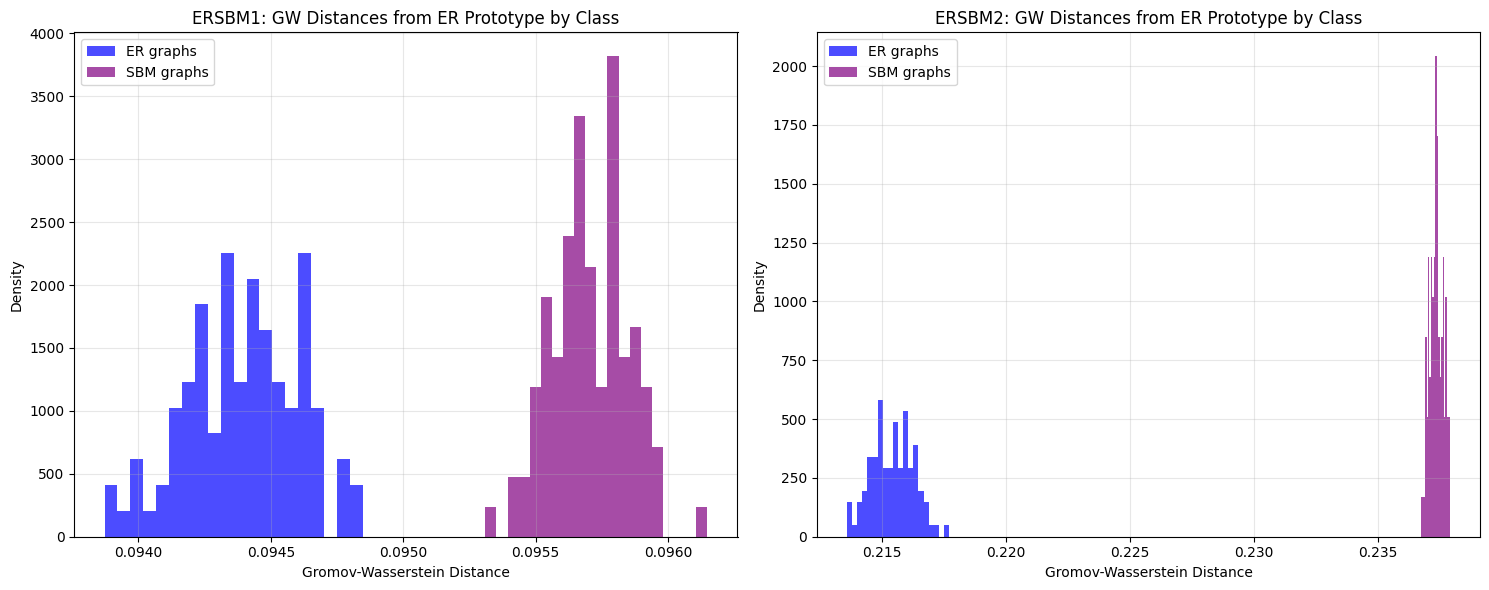

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ERSBM1 subplot
ax1.hist(gw_distances_er_to_er_proto, bins=20, alpha=0.7, label='ER graphs', color='blue', density=True)
ax1.hist(gw_distances_sbm_to_er_proto, bins=20, alpha=0.7, label='SBM graphs', color='purple', density=True)
ax1.set_xlabel('Gromov-Wasserstein Distance')
ax1.set_ylabel('Density')
ax1.set_title('ERSBM1: GW Distances from ER Prototype by Class')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ERSBM2 subplot
ax2.hist(gw_distances_er5_to_er_proto, bins=20, alpha=0.7, label='ER graphs', color='blue', density=True)
ax2.hist(gw_distances_sbm5_to_er_proto, bins=20, alpha=0.7, label='SBM graphs', color='purple', density=True)
ax2.set_xlabel('Gromov-Wasserstein Distance')
ax2.set_ylabel('Density')
ax2.set_title('ERSBM2: GW Distances from ER Prototype by Class')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("\nERSBM1 Summary Statistics:")
print(f"ER graphs - Mean: {np.mean(gw_distances_er_to_er_proto):.4f}, Std: {np.std(gw_distances_er_to_er_proto):.4f}")
print(f"SBM graphs - Mean: {np.mean(gw_distances_sbm_to_er_proto):.4f}, Std: {np.std(gw_distances_sbm_to_er_proto):.4f}")

print("\nERSBM2 Summary Statistics:")
print(f"ER graphs - Mean: {np.mean(gw_distances_er5_to_er_proto):.4f}, Std: {np.std(gw_distances_er5_to_er_proto):.4f}")
print(f"SBM graphs - Mean: {np.mean(gw_distances_sbm5_to_er_proto):.4f}, Std: {np.std(gw_distances_sbm5_to_er_proto):.4f}")


ERSBM1 Summary Statistics:
ER graphs - Mean: 0.0944, Std: 0.0002
SBM graphs - Mean: 0.0957, Std: 0.0001

ERSBM2 Summary Statistics:
ER graphs - Mean: 0.2154, Std: 0.0008
SBM graphs - Mean: 0.2374, Std: 0.0003


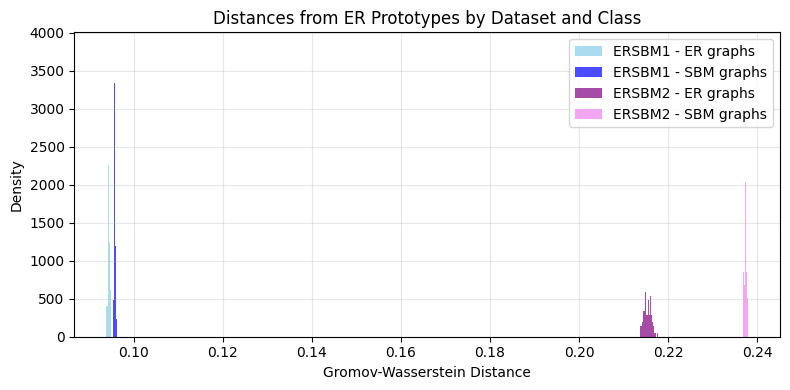


Combined Summary Statistics:
ERSBM1 - ER graphs - Mean: 0.0944, Std: 0.0002
ERSBM1 - SBM graphs - Mean: 0.0957, Std: 0.0001
ERSBM2 - ER graphs - Mean: 0.2154, Std: 0.0008
ERSBM2 - SBM graphs - Mean: 0.2374, Std: 0.0003


In [12]:
plt.figure(figsize=(8, 4))

# Plot all four distributions
plt.hist(gw_distances_er_to_er_proto, bins=20, alpha=0.7, label='ERSBM1 - ER graphs', color='skyblue', density=True)
plt.hist(gw_distances_sbm_to_er_proto, bins=20, alpha=0.7, label='ERSBM1 - SBM graphs', color='blue', density=True)
plt.hist(gw_distances_er5_to_er_proto, bins=20, alpha=0.7, label='ERSBM2 - ER graphs', color='purple', density=True)
plt.hist(gw_distances_sbm5_to_er_proto, bins=20, alpha=0.7, label='ERSBM2 - SBM graphs', color='violet', density=True)

plt.xlabel('Gromov-Wasserstein Distance')
plt.ylabel('Density')
plt.title('Distances from ER Prototypes by Dataset and Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCombined Summary Statistics:")
print(f"ERSBM1 - ER graphs - Mean: {np.mean(gw_distances_er_to_er_proto):.4f}, Std: {np.std(gw_distances_er_to_er_proto):.4f}")
print(f"ERSBM1 - SBM graphs - Mean: {np.mean(gw_distances_sbm_to_er_proto):.4f}, Std: {np.std(gw_distances_sbm_to_er_proto):.4f}")
print(f"ERSBM2 - ER graphs - Mean: {np.mean(gw_distances_er5_to_er_proto):.4f}, Std: {np.std(gw_distances_er5_to_er_proto):.4f}")
print(f"ERSBM2 - SBM graphs - Mean: {np.mean(gw_distances_sbm5_to_er_proto):.4f}, Std: {np.std(gw_distances_sbm5_to_er_proto):.4f}")

In [13]:
### Impossible case: ERSBM3 ###
## Using "Proof of Block Model Threshold" paper parameters

# ERSBM3
prob_matrix3 = [
    [0.11, 0.09],  # Probabilities related to block 1 connections
    [0.09, 0.11]  # Probabilities related to block 2 connections
]

graphs_er3 = generate_erdos_renyi_graphs(100, 100, 0.1)
graphs_sbm3 = generate_sbm_graphs(100, [50, 50], prob_matrix3)

full_graph_data3 = graphs_er3 + graphs_sbm3
# Convert graphs to pairwise distance matrices
# distance_matrices3 = [    compute_distance_matrix(graph) for graph, label in full_graph_data3]
# Prepare labels
labels3 = [label for graph, label in full_graph_data3]

In [14]:
graph33, ERSBM3_proto_ER = create_two_community_graph(50, 0.1, 0.1)
ERSBM3_adj_er = [
    compute_adjacency_matrix(graph, 0.1, 0.1) for graph, label in graphs_er3
]
ERSBM3_adj_sbm = [
    compute_adjacency_matrix(graph, 0.11, 0.09) for graph, label in graphs_sbm3
]

ERSBM3_adj = ERSBM3_adj_er + ERSBM3_adj_sbm

In [15]:
print("Computing Gromov-Wasserstein distances for ERSBM3")

# Distances from ERSBM3 graphs to ER prototype
gw_distances_er_to_er_proto3 = []
gw_distances_sbm_to_er_proto3 = []

for adj_matrix in ERSBM3_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM3_proto_ER)
    gw_distances_er_to_er_proto3.append(dist)

for adj_matrix in ERSBM3_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM3_proto_ER)
    gw_distances_sbm_to_er_proto3.append(dist)

print("ERSBM3 complete")

Computing Gromov-Wasserstein distances for ERSBM3
ERSBM3 complete


In [16]:
ersbm3_distances = (gw_distances_er_to_er_proto3 + gw_distances_sbm_to_er_proto3)

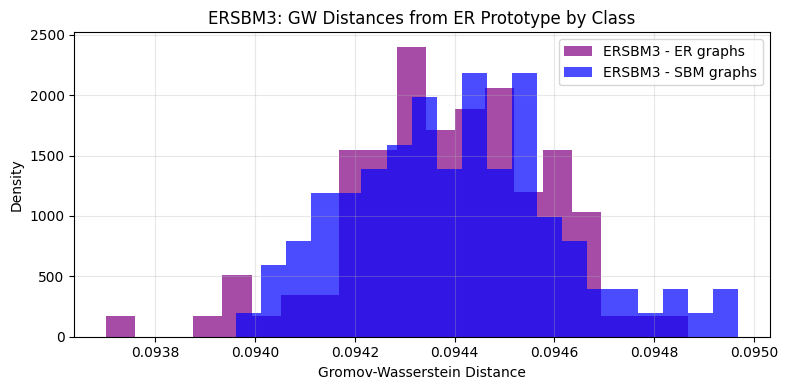

In [17]:
plt.figure(figsize=(8, 4))

# Plot all four distributions
plt.hist(gw_distances_er_to_er_proto3, bins=20, alpha=0.7, label='ERSBM3 - ER graphs', color='purple', density=True)
plt.hist(gw_distances_sbm_to_er_proto3, bins=20, alpha=0.7, label='ERSBM3 - SBM graphs', color='blue', density=True)

plt.xlabel('Gromov-Wasserstein Distance')
plt.ylabel('Density')
plt.title('ERSBM3: GW Distances from ER Prototype by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
### Parameter Optimization for ERSBM4 ###
# s = (a-b)/2
# d = (a+b)/2

print("\n" + "="*60)
print("OPTIMIZING PARAMETERS FOR ERSBM4")
print("="*60)

best_a, best_b = None, None
best_difference_ratio = float('inf')

# Search over reasonable ranges for a and b
# We'll search with fine granularity to find the optimal values
print("Searching for optimal a and b parameters...")

for a in np.arange(100.0, 150.0, 0.01):
    for b in np.arange(100.0, 150.0, 0.01):
        s = (a - b) / 2
        d = (a + b) / 2
        s_squared = s ** 2
        
        # Check if s^2 > d
        if s_squared > d:
            # Calculate the percentage difference
            difference_ratio = abs(s_squared - d) / d
            
            # Check if this is approximately .5% (at least .5% but close to it)
            if difference_ratio >= 0.005 and difference_ratio < best_difference_ratio:
                best_difference_ratio = difference_ratio
                best_a, best_b = a, b

if best_a is not None and best_b is not None:
    best_s = (best_a - best_b) / 2
    best_d = (best_a + best_b) / 2
    best_s_squared = best_s ** 2
    
    print(f"Optimal parameters found:")
    print(f"a = {best_a:.4f}")
    print(f"b = {best_b:.4f}")
    print(f"s = (a-b)/2 = {best_s:.4f}")
    print(f"d = (a+b)/2 = {best_d:.4f}")
    print(f"s² = {best_s_squared:.4f}")
    print(f"s² - d = {best_s_squared - best_d:.6f}")
    print(f"Percentage difference: {best_difference_ratio*100:}%")
    print(f"Constraint s² > d: {best_s_squared > best_d}")
    
    # Use the optimized parameters
    a = best_a
    b = best_b
else:
    print("No parameters found within 1% tolerance. Using fallback values.")
    a = 4.74
    b = 1.25


OPTIMIZING PARAMETERS FOR ERSBM4
Searching for optimal a and b parameters...
Optimal parameters found:
a = 110.5500
b = 132.6600
s = (a-b)/2 = -11.0550
d = (a+b)/2 = 121.6050
s² = 122.2130
s² - d = 0.608025
Percentage difference: 0.5000000000936985%
Constraint s² > d: True


In [19]:
n=1000

In [20]:
### More difficult case: ERSBM4 ###
## Using "Proof of Block Model Threshold" paper parameters. These parameters satisfy s^2 > d, but the numbers are very close
# ERSBM4
prob_matrix4 = [
    [a/n, b/n],  # Probabilities related to block 1 connections
    [b/n, a/n]  # Probabilities related to block 2 connections
]

graphs_er4 = generate_erdos_renyi_graphs(100, n, ((a/n)+(b/n))/2)
graphs_sbm4 = generate_sbm_graphs(100, [int(n/2), int(n/2)], prob_matrix4)

full_graph_data4 = graphs_er4 + graphs_sbm4
# Convert graphs to pairwise distance matrices
# distance_matrices4 = [    compute_distance_matrix(graph) for graph, label in full_graph_data4]
# Prepare labels
labels4 = [label for graph, label in full_graph_data4]

print("Within-class EAP:", a/n)
print("Between-class EAP:", b/n)

Within-class EAP: 0.1105500000000054
Between-class EAP: 0.1326600000000167


In [21]:
graph4, ERSBM4_proto_ER = create_two_community_graph(int(n/2), ((a/n)+(b/n))/2, ((a/n)+(b/n))/2)
ERSBM4_adj_er = [
    compute_adjacency_matrix(graph, ((a/n)+(b/n))/2, ((a/n)+(b/n))/2) for graph, label in graphs_er4
]
ERSBM4_adj_sbm = [
    compute_adjacency_matrix(graph, a/n, b/n) for graph, label in graphs_sbm4
]

ERSBM4_adj = ERSBM4_adj_er + ERSBM4_adj_sbm

In [22]:
print("Computing Gromov-Wasserstein distances for ERSBM4")

# Distances from ERSBM4 graphs to ER prototype
gw_distances_er_to_er_proto4 = []
gw_distances_sbm_to_er_proto4 = []

for adj_matrix in ERSBM4_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM4_proto_ER)
    gw_distances_er_to_er_proto4.append(dist)

for adj_matrix in ERSBM4_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM4_proto_ER)
    gw_distances_sbm_to_er_proto4.append(dist)

print("ERSBM4 complete")

Computing Gromov-Wasserstein distances for ERSBM4
ERSBM4 complete


In [23]:
ersbm4_distances = (gw_distances_er_to_er_proto4 + gw_distances_sbm_to_er_proto4)

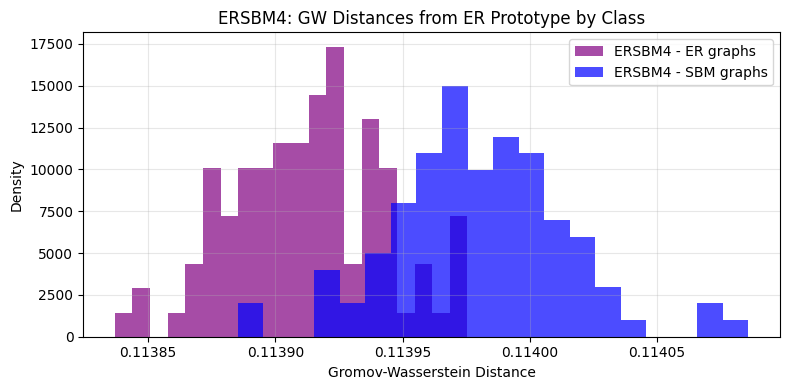

In [24]:
plt.figure(figsize=(8, 4))

# Plot all four distributions
plt.hist(gw_distances_er_to_er_proto4, bins=20, alpha=0.7, label='ERSBM4 - ER graphs', color='purple', density=True)
plt.hist(gw_distances_sbm_to_er_proto4, bins=20, alpha=0.7, label='ERSBM4 - SBM graphs', color='blue', density=True)

plt.xlabel('Gromov-Wasserstein Distance')
plt.ylabel('Density')
plt.title('ERSBM4: GW Distances from ER Prototype by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
print("\n" + "="*60)
print("OPTIMIZING PARAMETERS FOR IMPOSSIBLE CASE (s² < d)")
print("="*60)

best_a_im, best_b_im = None, None
best_difference_ratio_im = float('inf')

# Search over reasonable ranges for a_im and b_im
print("Searching for optimal a and b parameters where s² < d...")

for a_im in np.arange(165.0, 190.0, 0.01):
    for b_im in np.arange(165.0, 190.0, 0.01):
        s_im = (a_im - b_im) / 2
        d_im = (a_im + b_im) / 2
        s_squared_im = s_im ** 2
        
        # Check if s^2 < d (the impossible case)
        if s_squared_im < d_im:
            # Calculate the percentage difference
            difference_ratio_im = abs(s_squared_im - d_im) / d_im
            
            if difference_ratio_im >= 0.45 and difference_ratio_im < best_difference_ratio_im:
                best_difference_ratio_im = difference_ratio_im
                best_a_im, best_b_im = a_im, b_im

if best_a_im is not None and best_b_im is not None:
    best_s_im = (best_a_im - best_b_im) / 2
    best_d_im = (best_a_im + best_b_im) / 2
    best_s_squared_im = best_s_im ** 2
    
    print(f"Optimal parameters found for impossible case:")
    print(f"a_im = {best_a_im:.4f}")
    print(f"b_im = {best_b_im:.4f}")
    print(f"s = (a_im-b_im)/2 = {best_s_im:.4f}")
    print(f"d = (a_im+b_im)/2 = {best_d_im:.4f}")
    print(f"s² = {best_s_squared_im:.4f}")
    print(f"s² - d = {best_s_squared_im - best_d_im:}")
    print(f"Percentage difference: {best_difference_ratio_im*100:}%")
    print(f"Constraint s² < d: {best_s_squared_im < best_d_im}")
    
    # Use the optimized parameters for impossible case
    a_im = best_a_im
    b_im = best_b_im
else:
    print("No parameters found with at least 45% difference for impossible case. Using fallback values.")
    a_im = 1.0
    b_im = 2.0


OPTIMIZING PARAMETERS FOR IMPOSSIBLE CASE (s² < d)
Searching for optimal a and b parameters where s² < d...
Optimal parameters found for impossible case:
a_im = 168.3000
b_im = 188.1000
s = (a_im-b_im)/2 = -9.9000
d = (a_im+b_im)/2 = 178.2000
s² = 98.0100
s² - d = -80.19000000016628
Percentage difference: 45.00000000009634%
Constraint s² < d: True


In [34]:
prob_matrix55 = [
    [a_im/n, b_im/n],  # Probabilities related to block 1 connections
    [b_im/n, a_im/n]  # Probabilities related to block 2 connections
]

graphs_er55 = generate_erdos_renyi_graphs(100, n, ((a_im/n)+(b_im/n))/2)
graphs_sbm55 = generate_sbm_graphs(100, [int(n/2), int(n/2)], prob_matrix55)

full_graph_data55 = graphs_er55 + graphs_sbm55
# Convert graphs to pairwise distance matrices
# distance_matrices55 = [    compute_distance_matrix(graph) for graph, label in full_graph_data55]
# Prepare labels
labels55 = [label for graph, label in full_graph_data55]

print("Within-class EAP:", a_im/n)
print("Between-class EAP:", b_im/n)

Within-class EAP: 0.168299999999997
Between-class EAP: 0.18809999999997898


In [35]:
graph55, ERSBM5_proto_ER = create_two_community_graph(int(n/2), ((a_im/n)+(b_im/n))/2, ((a_im/n)+(b_im/n))/2)
ERSBM5_adj_er = [
    compute_adjacency_matrix(graph, ((a_im/n)+(b_im/n))/2, ((a_im/n)+(b_im/n))/2) for graph, label in graphs_er55
]
ERSBM5_adj_sbm = [
    compute_adjacency_matrix(graph, a_im/n, b_im/n) for graph, label in graphs_sbm55
]

ERSBM5_adj = ERSBM5_adj_er + ERSBM5_adj_sbm

In [36]:
print("Computing Gromov-Wasserstein distances for ERSBM5")

# Distances from ERSBM5 graphs to ER prototype
gw_distances_er_to_er_proto5 = []
gw_distances_sbm_to_er_proto5 = []

for adj_matrix in ERSBM5_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM5_proto_ER)
    gw_distances_er_to_er_proto5.append(dist)

for adj_matrix in ERSBM5_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM5_proto_ER)
    gw_distances_sbm_to_er_proto5.append(dist)

print("ERSBM5 complete")

Computing Gromov-Wasserstein distances for ERSBM5
ERSBM5 complete


In [37]:
ersbm5_distances = (gw_distances_er_to_er_proto5 + gw_distances_sbm_to_er_proto5)

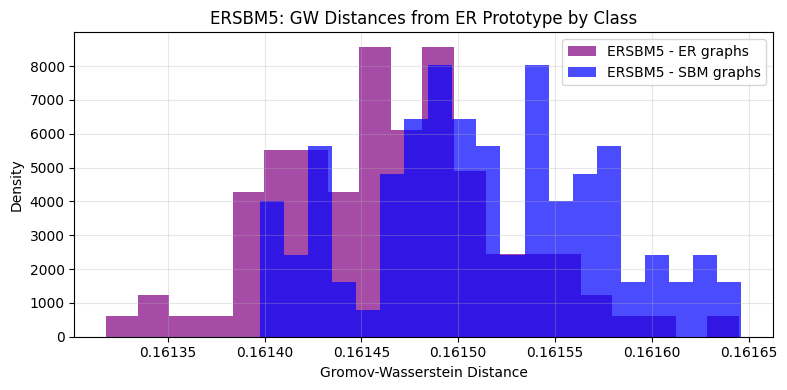

In [38]:
plt.figure(figsize=(8, 4))

# Plot all four distributions
plt.hist(gw_distances_er_to_er_proto5, bins=20, alpha=0.7, label='ERSBM5 - ER graphs', color='purple', density=True)
plt.hist(gw_distances_sbm_to_er_proto5, bins=20, alpha=0.7, label='ERSBM5 - SBM graphs', color='blue', density=True)

plt.xlabel('Gromov-Wasserstein Distance')
plt.ylabel('Density')
plt.title('ERSBM5: GW Distances from ER Prototype by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
def prototype_classifier(adj_matrices, prototype, labels, num_folds=5, method="kfold", threshold_method="grid_search", seed=42, log=False):
    """
    Classify graphs based on GW distances from a prototype using a horizontal threshold.
    
    Parameters:
    adj_matrices: List of weighted adjacency matrices
    prototype: The prototype adjacency matrix
    labels: List of labels (1 for ER, -1 for SBM)
    num_folds: Number of folds for cross-validation
    method: Cross-validation method, either "kfold" (for k-fold CV) or "stratk" (for stratified k-fold CV)
    threshold_method: Method for finding optimal threshold ("grid_search", "logistic_regression", "roc_optimization", "youden_j")
    seed: Random seed for reproducibility
    log: Boolean flag to print additional information
    
    Returns:
    class_acc_list: List of classification accuracies for each fold
    negone_acc_list: List of classification accuracies for class -1 for each fold
    one_acc_list: List of classification accuracies for class 1 for each fold
    f1_score_list: List of F1 scores for each fold
    thresholds_list: List of optimal thresholds found for each fold
    """
    # Compute GW distances from prototype
    distances = []
    for adj_matrix in adj_matrices:
        dist = compute_gromov_wasserstein_distance(adj_matrix, prototype)
        distances.append(dist)
    
    distances = np.array(distances)
    labels = np.array(labels)
    
    # Initialize lists to store results
    class_acc_list = []  # list to store classification accuracies from each fold
    negone_acc_list = []  # list to store class -1 accuracies from each fold
    one_acc_list = []  # list to store class 1 accuracies from each fold
    f1_score_list = []  # list to store F1 scores from each fold
    thresholds_list = []  # list to store optimal thresholds from each fold
    
    # Setup cross-validation method
    assert method in ["kfold", "stratk"]
    if method == "kfold":
        from sklearn.model_selection import KFold
        k_folds = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
        print("k-fold CV selected")
    else:
        from sklearn.model_selection import StratifiedKFold
        k_folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
        print("Stratified k-fold CV selected")
    
    start = time.time()
    
    for i, (train_idx, test_idx) in enumerate(k_folds.split(distances, labels)):
        print(f"Fold {i}:")
        if log is True:
            print(f"  Train: index={train_idx}")
            print(f"  Test:  index={test_idx}")
        
        # Split data
        train_distances = distances[train_idx]
        train_labels = labels[train_idx]
        test_distances = distances[test_idx]
        test_labels = labels[test_idx]
        
        # Find optimal threshold using specified method
        if threshold_method == "grid_search":
            best_threshold = _find_threshold_grid_search(train_distances, train_labels)
        elif threshold_method == "logistic_regression":
            best_threshold = _find_threshold_logistic_regression(train_distances, train_labels)
        elif threshold_method == "roc_optimization":
            best_threshold = _find_threshold_roc_optimization(train_distances, train_labels)
        elif threshold_method == "youden_j":
            best_threshold = _find_threshold_youden_j(train_distances, train_labels)
        else:
            raise ValueError(f"Unknown threshold_method: {threshold_method}")
        
        if best_threshold is None:
            # Fallback to simple grid search
            print(f"  Warning: {threshold_method} failed, falling back to grid search for fold {i}")
            best_threshold = _find_threshold_grid_search(train_distances, train_labels)
        
        thresholds_list.append(best_threshold)
        if log is True:
            print(f"  Optimal threshold: {best_threshold:.4f}")
        
        # Apply best threshold to test data
        test_predictions = np.where(test_distances <= best_threshold, 1, -1)
        
        # Compute metrics
        overall_accuracy = accuracy_score(test_labels, test_predictions) * 100
        
        # Class-specific accuracies
        class_neg1_mask = test_labels == -1
        class_pos1_mask = test_labels == 1
        
        correct_count_negone = 0
        correct_count_one = 0
        total_count_negone = np.sum(class_neg1_mask)
        total_count_one = np.sum(class_pos1_mask)
        
        if total_count_negone > 0:
            class_neg1_acc = accuracy_score(test_labels[class_neg1_mask], test_predictions[class_neg1_mask]) * 100
            negone_acc_list.append(class_neg1_acc)
        
        if total_count_one > 0:
            class_pos1_acc = accuracy_score(test_labels[class_pos1_mask], test_predictions[class_pos1_mask]) * 100
            one_acc_list.append(class_pos1_acc)
        
        # F1 score
        average_type = "macro" if method == "kfold" else "weighted"
        f1_weighted = f1_score(test_labels, test_predictions, average=average_type) * 100
        
        # Store results
        class_acc_list.append(overall_accuracy)
        f1_score_list.append(f1_weighted)
        
        # Print fold results
        print(f"F1 Score ({average_type} avg): {f1_weighted:.2f}%, Fold {i}")
        print(f"Classification Accuracy: {overall_accuracy:.2f}%, Fold {i}")
        if total_count_negone > 0:
            print(f"Classification Accuracy for Class -1: {class_neg1_acc:.2f}%, Fold {i}")
        if total_count_one > 0:
            print(f"Classification Accuracy for Class 1: {class_pos1_acc:.2f}%, Fold {i}")
    
    end = time.time()
    print("Total runtime, seconds: ")
    print(end - start)

    # Compute and print averages and standard deviations
    print("\n" + "=" * 50)
    print("SUMMARY STATISTICS")
    print("=" * 50)

    avg_classification_acc = np.mean(class_acc_list)
    std_classification_acc = np.std(class_acc_list)
    print(f"Overall Classification Accuracy: {avg_classification_acc:.2f}% ± {std_classification_acc:.2f}%")

    avg_negone_acc = np.mean(negone_acc_list)
    std_negone_acc = np.std(negone_acc_list)
    print(f"Class -1 Classification Accuracy: {avg_negone_acc:.2f}% ± {std_negone_acc:.2f}%")

    avg_one_acc = np.mean(one_acc_list)
    std_one_acc = np.std(one_acc_list)
    print(f"Class 1 Classification Accuracy: {avg_one_acc:.2f}% ± {std_one_acc:.2f}%")

    avg_f1_score = np.mean(f1_score_list)
    std_f1_score = np.std(f1_score_list)
    average_type = "macro" if method == "kfold" else "weighted"
    print(f"F1 Score ({average_type} avg): {avg_f1_score:.2f}% ± {std_f1_score:.2f}%")

    return class_acc_list, negone_acc_list, one_acc_list, f1_score_list, thresholds_list


def _find_threshold_grid_search(train_distances, train_labels):
    """Original grid search method using midpoints between unique distances."""
    unique_distances = np.unique(train_distances)
    thresholds = (unique_distances[:-1] + unique_distances[1:]) / 2
    
    best_threshold = None
    best_train_accuracy = 0
    
    for threshold in thresholds:
        train_predictions = np.where(train_distances <= threshold, 1, -1)
        train_accuracy = accuracy_score(train_labels, train_predictions)
        
        if train_accuracy > best_train_accuracy:
            best_train_accuracy = train_accuracy
            best_threshold = threshold
            
    print(f"Grid search optimal threshold: {best_threshold:.6f}" )
    
    return best_threshold


def _find_threshold_logistic_regression(train_distances, train_labels):
    """Use logistic regression to find optimal decision boundary."""
    try:
        # Reshape for sklearn
        X = train_distances.reshape(-1, 1)
        y = train_labels
        
        # Check if we have both classes in training data
        unique_labels = np.unique(y)
        if len(unique_labels) < 2:
            print(f"Warning: Only one class ({unique_labels}) in training data for logistic regression")
            return None
        
        # Scale features to improve numerical stability
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Fit logistic regression with regularization to prevent extreme coefficients
        lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', C=1.0)
        lr.fit(X_scaled, y)
        
        # Check coefficient magnitude
        coef_magnitude = abs(lr.coef_[0][0])
        if coef_magnitude < 1e-6:
            print(f"Warning: Logistic regression coefficient too small ({coef_magnitude:.2e}), likely poor separability")
            return None
        
        if coef_magnitude > 1e6:
            print(f"Warning: Logistic regression coefficient too large ({coef_magnitude:.2e}), likely numerical issues")
            return None
        
        # The decision boundary in scaled space
        threshold_scaled = -lr.intercept_[0] / lr.coef_[0][0]
        
        # Transform back to original scale
        # For StandardScaler: original = scaled * std + mean
        threshold = threshold_scaled * scaler.scale_[0] + scaler.mean_[0]
        
        # Sanity check: threshold should be within reasonable range
        min_dist, max_dist = np.min(train_distances), np.max(train_distances)
        range_buffer = (max_dist - min_dist) * 0.5  # Allow 50% buffer outside range
        
        if threshold < min_dist - range_buffer or threshold > max_dist + range_buffer:
            print(f"Warning: Logistic regression threshold {threshold:.6f} outside reasonable range [{min_dist:.6f}, {max_dist:.6f}]")
            print(f"  Coefficient: {lr.coef_[0][0]:.6f}, Intercept: {lr.intercept_[0]:.6f}")
            print(f"  Scaled threshold: {threshold_scaled:.6f}")
            return None
        
        # Additional check: see how well the threshold performs on training data
        train_predictions = np.where(train_distances <= threshold, 1, -1)
        train_accuracy = accuracy_score(train_labels, train_predictions)
        
        #if train_accuracy < 0.55:  # If accuracy is barely better than random
        #    print(f"Warning: Logistic regression threshold gives poor training accuracy ({train_accuracy:.3f})")
        #    return None
            
        print(f"  Logistic regression threshold: {threshold:.6f} (training accuracy: {train_accuracy:.3f})")
        return threshold
        
    except Exception as e:
        print(f"Error in logistic regression threshold finding: {str(e)}")
        return None

In [40]:
# Test different threshold methods
threshold_methods = ["grid_search", "logistic_regression"]

for thresh_method in threshold_methods:
    print(f"\n{'-'*20} {thresh_method.upper()} METHOD {'-'*20}")
    
    print(f"\nEvaluating ERSBM1 dataset with {thresh_method}...")
    ersbm1_class_acc, ersbm1_negone_acc, ersbm1_one_acc, ersbm1_f1, ersbm1_thresholds = prototype_classifier(
        ERSBM1_adj, ERSBM1_proto_ER, labels, num_folds=10, method="kfold", threshold_method=thresh_method, log=False)
    
    print(f"\nEvaluating ERSBM2 dataset with {thresh_method}...")
    ersbm2_class_acc, ersbm2_negone_acc, ersbm2_one_acc, ersbm2_f1, ersbm2_thresholds = prototype_classifier(
        ERSBM2_adj, ERSBM2_proto_ER, labels5, num_folds=10, method="kfold", threshold_method=thresh_method, log=False)

    print(f"\nEvaluating ERSBM3 dataset with {thresh_method}...")
    ersbm3_class_acc, ersbm3_negone_acc, ersbm3_one_acc, ersbm3_f1, ersbm3_thresholds = prototype_classifier(
        ERSBM3_adj, ERSBM3_proto_ER, labels3, num_folds=10, method="kfold", threshold_method=thresh_method, log=False)
    
    print(f"\nEvaluating ERSBM4 dataset with {thresh_method}...")
    ersbm4_class_acc, ersbm4_negone_acc, ersbm4_one_acc, ersbm4_f1, ersbm4_thresholds = prototype_classifier(
        ERSBM4_adj, ERSBM4_proto_ER, labels4, num_folds=10, method="kfold", threshold_method=thresh_method, log=False)

    print(f"\nEvaluating ERSBM5 dataset with {thresh_method}...")
    ersbm5_class_acc, ersbm5_negone_acc, ersbm5_one_acc, ersbm5_f1, ersbm5_thresholds = prototype_classifier(
        ERSBM5_adj, ERSBM5_proto_ER, labels55, num_folds=10, method="kfold", threshold_method=thresh_method, log=False)


-------------------- GRID_SEARCH METHOD --------------------

Evaluating ERSBM1 dataset with grid_search...
k-fold CV selected
Fold 0:
Grid search optimal threshold: 0.095079
F1 Score (macro avg): 100.00%, Fold 0
Classification Accuracy: 100.00%, Fold 0
Classification Accuracy for Class -1: 100.00%, Fold 0
Classification Accuracy for Class 1: 100.00%, Fold 0
Fold 1:
Grid search optimal threshold: 0.095130
F1 Score (macro avg): 100.00%, Fold 1
Classification Accuracy: 100.00%, Fold 1
Classification Accuracy for Class -1: 100.00%, Fold 1
Classification Accuracy for Class 1: 100.00%, Fold 1
Fold 2:
Grid search optimal threshold: 0.095079
F1 Score (macro avg): 100.00%, Fold 2
Classification Accuracy: 100.00%, Fold 2
Classification Accuracy for Class -1: 100.00%, Fold 2
Classification Accuracy for Class 1: 100.00%, Fold 2
Fold 3:
Grid search optimal threshold: 0.095079
F1 Score (macro avg): 100.00%, Fold 3
Classification Accuracy: 100.00%, Fold 3
Classification Accuracy for Class -1: 100.0